# Notebook 05 — Modèle Elastic Net (affichage des résultats)

**Ce que le script a fait :**
1. Construire les mêmes **fenêtres** qu'au notebook 04
2. Pour **chaque fenêtre**, chercher les meilleurs hyperparamètres `(alpha, l1_ratio)` sur
   la **validation de cette fenêtre** (jamais de validation croisée aléatoire), puis
   ré-entraîner et évaluer une seule fois sur son test
3. Mettre bout à bout les prédictions et calculer le **R²_oos à la GKX**
4. Mesurer la **stabilité de la sélection de variables** sur toutes les fenêtres (section 6bis)
5. Sauvegarder modèle, prédictions, résultats, et ajouter une ligne au journal

## 0. Import et chargement des résultats

In [1]:
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
import rapports

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

rap = rapports.charger('05_elastic_net')
print(rap.resume())

resultats_finaux = pd.read_parquet(config.FICHIER_RESULTATS_ELASTIC_NET)
resultats_par_fenetre = pd.read_parquet(config.FICHIER_RESULTATS_ELASTIC_NET_PAR_FENETRE)

Rapport '05_elastic_net' produit le 2026-08-26T07:25:24


## 1. Données et fenêtres d'entraînement

In [2]:
print(f"Panel complet : {tuple(rap.valeur('shape_panel'))}")
print(f"Periode disponible dans le panel : {rap.valeur('periode_panel')[0]} a {rap.valeur('periode_panel')[1]}")
print(f"Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : {rap.valeur('annee_debut_entrainement')}")
print(f"Panel effectivement utilise : {tuple(rap.valeur('shape_panel_entrainement'))} "
      f"({rap.valeur('periode_entrainement')[0]} a {rap.valeur('periode_entrainement')[1]})")
print(f"Mode : {rap.valeur('type_fenetre')} | {rap.valeur('n_fenetres')} fenetres generees")
print(f"Predicteurs : {rap.valeur('n_predicteurs')}")
rap.table('resume_fenetres')

Panel complet : (2615807, 49)
Periode disponible dans le panel : 198002 a 202112
Debut d'entrainement impose (config.ANNEE_DEBUT_ENTRAINEMENT) : 1980
Panel effectivement utilise : (2615807, 49) (198002 a 202112)
Mode : rolling | 12 fenetres generees
Predicteurs : 30


,fenetre,train_debut,train_fin,n_mois_train,n_annees_train,validation_debut,validation_fin,n_annees_validation,test_debut,test_fin,annee_test
0,0,198002,199712,215,18,199801,200912,12,201001,201012,2010
1,1,198201,199912,216,18,200001,201012,11,201101,201112,2011
2,2,198401,200112,216,18,200201,201112,10,201201,201212,2012
3,3,198601,200312,216,18,200401,201212,9,201301,201312,2013
4,4,198801,200512,216,18,200601,201312,8,201401,201412,2014
5,5,199001,200712,216,18,200801,201412,7,201501,201512,2015
6,6,199201,200912,216,18,201001,201512,6,201601,201612,2016
7,7,199401,201112,216,18,201201,201612,5,201701,201712,2017
8,8,199601,201312,216,18,201401,201712,4,201801,201812,2018
9,9,199701,201412,216,18,201501,201812,4,201901,201912,2019


## 2. Le R² hors-échantillon à la Gu, Kelly & Xiu (2020)

Même métrique que les notebooks 04 et 06, indispensable pour rester comparable :

`R²_oos = 1 - Σ(y - ŷ)² / Σ(y²)`

## 3. Recherche d'hyperparamètres, fenêtre par fenêtre

L'Elastic Net a 2 hyperparamètres : `alpha` (force globale de la régularisation) et
`l1_ratio` (équilibre entre Lasso et Ridge). Pour **chaque fenêtre**, le script teste toute
la grille de `config.py`, chaque combinaison entraînée sur le `train` de cette fenêtre et
évaluée sur sa `validation` — **jamais** de validation croisée aléatoire (`cross_val_score`
classique), qui mélangerait des périodes temporelles différentes et créerait une fuite.

⚠️ Le `test` de chaque fenêtre ne sert **qu'une seule fois**, à la toute fin, une fois les
hyperparamètres déjà choisis sur la `validation` de cette même fenêtre.

In [3]:
print("Parametres SPECIFIQUES utilises (config.py) :")
for cle, valeur in rap.valeur('params_specifiques').items():
    print(f"  {cle} = {valeur}")
print()
print(f"Duree totale (recherche d'hyperparametres incluse) : "
      f"{rap.valeur('duree_entrainement_secondes'):.1f} s")
print()
resultats_par_fenetre

Parametres SPECIFIQUES utilises (config.py) :
  grille_alpha = [0.0001, 0.001]
  grille_l1_ratio = [0.1, 0.3, 0.5, 0.7, 0.9]
  max_iter = 1000

Duree totale (recherche d'hyperparametres incluse) : 716.4 s



,fenetre,annee_test,n_train,alpha,l1_ratio,r2_oos_train,r2_oos_validation,r2_oos_test
0,0,2010,1106697,0.0001,0.3,0.006281,0.001537,0.008911
1,1,2011,1227639,0.0010,0.1,0.005335,0.002051,-0.006251
2,2,2012,1300561,0.0010,0.3,0.004009,0.002041,0.007247
3,3,2013,1314690,0.0010,0.9,0.003031,0.001236,0.026004
4,4,2014,1315628,0.0010,0.9,0.003478,0.002234,-0.001827
5,5,2015,1313001,0.0010,0.9,0.003191,0.002247,-0.006089
6,6,2016,1303842,0.0010,0.9,0.002658,0.005845,0.008538
7,7,2017,1278025,0.0010,0.7,0.002385,0.006871,0.007571
8,8,2018,1228236,0.0010,0.9,0.002816,0.002331,-0.015147
9,9,2019,1198983,0.0010,0.9,0.002601,-0.001259,0.009839


## 3bis. La grille complète : tous les modèles testés au dernier lancement

La section précédente ne montre que la combinaison **gagnante** de chaque fenêtre. Or le
script en a entraîné bien plus : `alpha` × `l1_ratio` combinaisons, **pour chaque fenêtre**.
Ne regarder que le gagnant laisse de côté l'information la plus utile — la **forme** de la
surface de performance.

Un optimum *plat* (plusieurs combinaisons voisines à performances quasi identiques) est un
bon signe : le choix est robuste, une légère erreur de réglage ne coûte presque rien. Un
optimum *pointu* (un seul point nettement au-dessus) doit alerter : il peut être un artefact
du bruit de cette période de validation précise.

ℹ️ Les tableaux ci-dessous concernent **uniquement le dernier lancement** du script (celui
qui a produit le rapport chargé en section 0). Pour comparer plusieurs lancements avec des
paramètres différents, c'est le notebook 08 qui s'en charge.

In [4]:
grille = rap.table('grille_complete')

print(f"{rap.valeur('n_combinaisons_grille')} combinaisons x {rap.valeur('n_fenetres')} fenetres "
      f"= {rap.valeur('n_modeles_entraines_grille')} modeles entraines au total.")
print()
print("Combinaison retenue par fenetre :")
display(grille[grille['selectionnee']][
    ['fenetre', 'annee_test', 'alpha', 'l1_ratio',
     'r2_oos_train', 'r2_oos_validation', 'ecart_train_validation']
].round(4).set_index('fenetre'))

def _etiquettes(valeurs):
    # 1e-05 plutot que 9.999999999999e-06 : les flottants d'une grille se lisent mieux en %g
    return [f"{v:g}" if isinstance(v, float) else str(v) for v in valeurs]


def tracer_heatmap(pivot, titre, etiquette_couleur, cmap, format_valeur="{:.4f}"):
    # Heatmap annotee a partir d'un tableau croise (2 hyperparametres en lignes/colonnes)
    valeurs = pivot.values.astype(float)
    fig, ax = plt.subplots(figsize=(1.7 * len(pivot.columns) + 3.5,
                                    0.75 * len(pivot.index) + 2.5))
    image = ax.imshow(valeurs, cmap=cmap, aspect='auto')

    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(_etiquettes(pivot.columns))
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(_etiquettes(pivot.index))
    ax.set_xlabel(pivot.columns.name)
    ax.set_ylabel(pivot.index.name)
    ax.set_title(titre)

    milieu = (np.nanmax(valeurs) + np.nanmin(valeurs)) / 2
    for i in range(valeurs.shape[0]):
        for j in range(valeurs.shape[1]):
            v = valeurs[i, j]
            if np.isnan(v):
                continue
            ax.text(j, i, format_valeur.format(v), ha='center', va='center',
                    fontsize=9, color='white' if v < milieu else 'black')

    fig.colorbar(image, ax=ax, label=etiquette_couleur)
    plt.tight_layout()
    plt.show()




10 combinaisons x 12 fenetres = 120 modeles entraines au total.

Combinaison retenue par fenetre :


,annee_test,alpha,l1_ratio,r2_oos_train,r2_oos_validation,ecart_train_validation
fenetre,,,,,,
0,2010,0.0001,0.3,0.0063,0.0015,0.0047
1,2011,0.0010,0.1,0.0053,0.0021,0.0033
2,2012,0.0010,0.3,0.0040,0.0020,0.0020
3,2013,0.0010,0.9,0.0030,0.0012,0.0018
4,2014,0.0010,0.9,0.0035,0.0022,0.0012
5,2015,0.0010,0.9,0.0032,0.0022,0.0009
6,2016,0.0010,0.9,0.0027,0.0058,-0.0032
7,2017,0.0010,0.7,0.0024,0.0069,-0.0045
8,2018,0.0010,0.9,0.0028,0.0023,0.0005


### R²_oos de validation, moyenné sur les fenêtres

⚠️ Chaque case est la **moyenne du R²_oos de validation sur toutes les fenêtres** pour cette
combinaison. Une combinaison peut donc y paraître médiocre tout en ayant gagné une fenêtre
particulière — le tableau détaillé plus bas permet de vérifier.

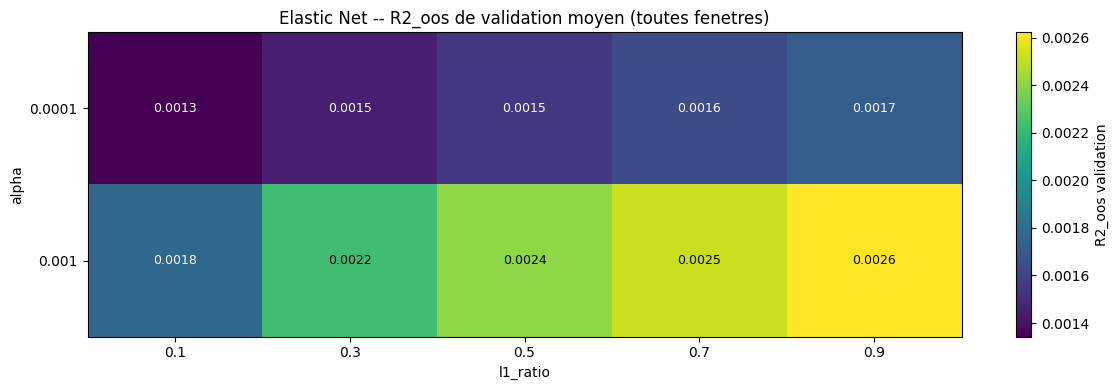

In [5]:
pivot_validation = grille.pivot_table(index='alpha', columns='l1_ratio',
                                      values='r2_oos_validation', aggfunc='mean')
tracer_heatmap(pivot_validation,
               "Elastic Net -- R2_oos de validation moyen (toutes fenetres)",
               "R2_oos validation", cmap='viridis')

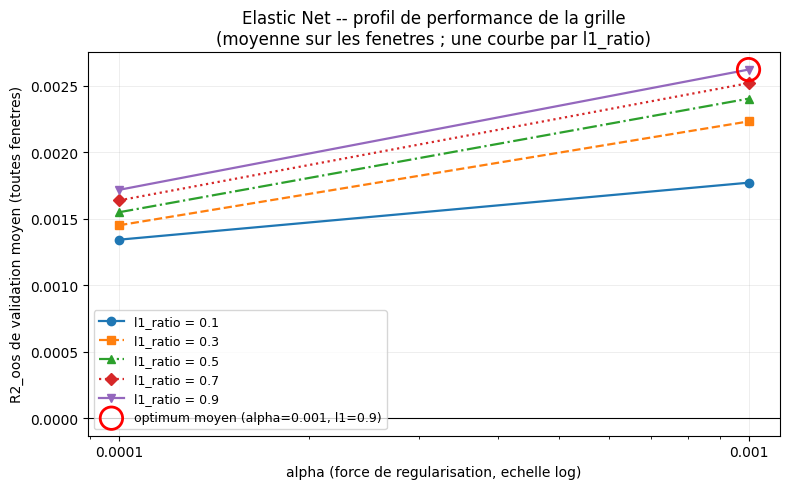

In [6]:
profils = grille.pivot_table(index='alpha', columns='l1_ratio',
                             values='r2_oos_validation', aggfunc='mean')

STYLES = ['-o', '--s', '-.^', ':D', '-v']

fig, ax = plt.subplots(figsize=(8, 5))
for style, l1 in zip(STYLES, profils.columns):
    ax.plot(profils.index, profils[l1], style, label=f"l1_ratio = {l1:g}",
            linewidth=1.6, markersize=6)

meilleur = profils.stack().idxmax()
ax.scatter([meilleur[0]], [profils.loc[meilleur]], s=260, facecolors='none',
           edgecolors='red', linewidths=2, zorder=5,
           label=f"optimum moyen (alpha={meilleur[0]:g}, l1={meilleur[1]:g})")

ax.set_xscale('log')
ax.set_xticks(config.GRILLE_ALPHA_ELASTIC_NET)
ax.set_xticklabels([f"{v:g}" for v in config.GRILLE_ALPHA_ELASTIC_NET])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel("alpha (force de regularisation, echelle log)")
ax.set_ylabel("R2_oos de validation moyen (toutes fenetres)")
ax.set_title("Elastic Net -- profil de performance de la grille\n"
             "(moyenne sur les fenetres ; une courbe par l1_ratio)")
ax.legend(fontsize=9)
ax.grid(alpha=0.25, linewidth=0.6)
plt.tight_layout()
plt.show()

In [7]:
resume_grille = (grille.groupby(['alpha', 'l1_ratio'])
                 .agg(r2_train=('r2_oos_train', 'mean'),
                      r2_validation=('r2_oos_validation', 'mean'),
                      ecart=('ecart_train_validation', 'mean'),
                      coefs_non_nuls=('n_coefficients_non_nuls', 'mean'),
                      fois_selectionnee=('selectionnee', 'sum'))
                 .sort_values('r2_validation', ascending=False))

print("Toutes les combinaisons, classees par R2_oos de validation moyen :")
resume_grille.round(4)

Toutes les combinaisons, classees par R2_oos de validation moyen :


r2_train  r2_validation   ecart  coefs_non_nuls  fois_selectionnee
alpha  l1_ratio                                                                    
0.0010 0.9         0.0029         0.0026  0.0003          7.7500                  8
       0.7         0.0032         0.0025  0.0007         10.2500                  1
       0.5         0.0035         0.0024  0.0011         15.3333                  0
       0.3         0.0041         0.0022  0.0019         22.0000                  1
       0.1         0.0046         0.0018  0.0028         27.4167                  1
0.0001 0.9         0.0046         0.0017  0.0029         27.9167                  0
       0.7         0.0046         0.0016  0.0030         28.5000                  0
       0.5         0.0047         0.0015  0.0031         28.5000                  0
       0.3         0.0047         0.0015  0.0032         29.0833                  1
       0.1         0.0047         0.0013  0.0033         29.5000                  0

### L'écart train − validation : quelle combinaison sur-apprend le moins ?

Le R²_oos de validation seul ne dit pas **comment** une combinaison arrive à son score. Deux
modèles peuvent obtenir la même validation avec des comportements opposés : l'un colle au
train et généralise mal, l'autre apprend peu mais transfère bien.

L'écart `R²_train − R²_validation` mesure directement cette différence :

- **Écart large et positif** → le modèle explique bien le passé mais beaucoup moins la
  période suivante : sur-apprentissage. Sur l'Elastic Net, c'est le symptôme d'un `alpha`
  trop faible (régularisation insuffisante).
- **Écart proche de zéro** → le modèle généralise ce qu'il a appris. C'est ce qu'on veut.
- **Écart négatif** (validation meilleure que train) → arrive avec un signal très faible et
  une forte régularisation : le modèle prédit presque zéro partout, et la période de
  validation lui est simplement plus favorable. Ce n'est pas un bon signe en soi, plutôt un
  indicateur que le modèle n'apprend quasiment rien.

⚠️ Cette section est un **diagnostic**, pas le critère utilisé par le script : la sélection
reste faite sur le meilleur R²_oos de validation. Si tu décides de sélectionner sur l'écart
(ou sur un compromis entre les deux), il faut changer le critère dans
`scripts/etape05_modele_elastic_net.py` — la ligne `index_meilleur = ...`.

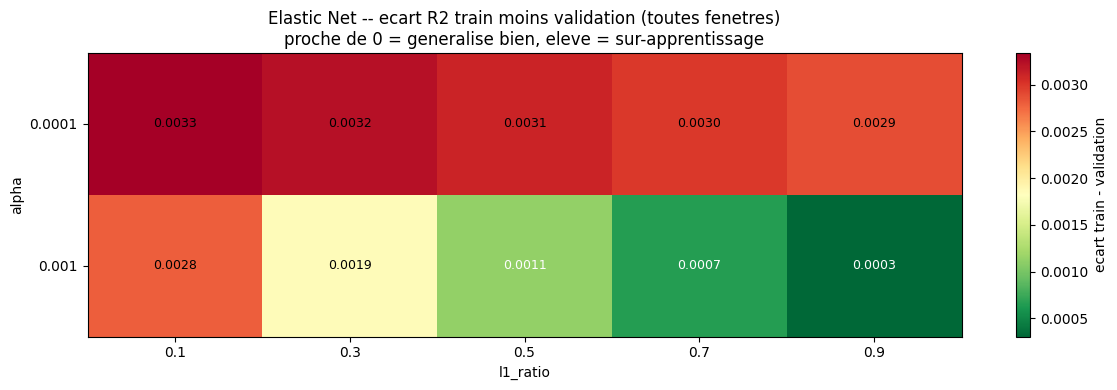

In [8]:
pivot_ecart = grille.pivot_table(index='alpha', columns='l1_ratio',
                                 values='ecart_train_validation', aggfunc='mean')
tracer_heatmap(pivot_ecart,
               "Elastic Net -- ecart R2 train moins validation (toutes fenetres)\n"
               "proche de 0 = generalise bien, eleve = sur-apprentissage",
               "ecart train - validation", cmap='RdYlGn_r')

## 4. Évaluation hors-échantillon pooled (toutes les fenêtres bout à bout)

⚠️ Comme au notebook 04 : on met toutes les prédictions bout à bout **d'abord**, puis on
calcule un seul R²_oos — pas une moyenne des R² par fenêtre, qui donnerait un poids
disproportionné aux fenêtres les plus courtes.

In [9]:
ligne = resultats_finaux.iloc[0]
print(f"R2_oos train      (pooled, toutes fenetres) : {ligne['r2_oos_train']:.4f}")
print(f"R2_oos validation (pooled, toutes fenetres) : {ligne['r2_oos_validation']:.4f}")
print(f"R2_oos test       (pooled, toutes fenetres) : {ligne['r2_oos_test']:.4f}")
print()
resultats_finaux

R2_oos train      (pooled, toutes fenetres) : 0.0033
R2_oos validation (pooled, toutes fenetres) : 0.0022
R2_oos test       (pooled, toutes fenetres) : 0.0039



,modele,type_fenetre,n_fenetres,r2_oos_train,r2_oos_validation,r2_oos_test,cle_experience
0,Elastic Net,rolling,12,0.003272,0.002241,0.003897,d0fb9c28582c3da7


## 5. Évolution du R²_oos et des hyperparamètres au fil des fenêtres

Le panneau de gauche montre le R²_oos de test fenêtre par fenêtre. Le panneau de droite
superpose les **deux** hyperparamètres retenus, sur deux axes Y distincts : `alpha` à gauche
(échelle log, orange) et `l1_ratio` à droite (échelle 0-1, vert). Les graduations sont
calées sur les valeurs de la grille de `config.py`, si bien qu'un point posé sur un bord de
l'axe signale une grille trop étroite plutôt qu'un véritable optimum.

Les deux paramètres ne disent pas la même chose :

- **`alpha` = *combien* on régularise.** S'il varie beaucoup d'une fenêtre à l'autre, la
  force de pénalisation optimale dépend fortement de la période. Ce n'est pas un défaut en
  soi, mais c'est un diagnostic qu'un jeu d'hyperparamètres unique, figé pour tout
  l'historique, ne pourrait pas révéler.
- **`l1_ratio` = *comment* on régularise**, entre sélection pure (1.0, Lasso : les
  coefficients sont annulés) et lissage des colinéarités (0.0, Ridge : les coefficients sont
  rétrécis mais conservés). Sur des caractéristiques d'entreprise fortement corrélées entre
  elles, une valeur qui reste basse est un résultat en soi : le modèle préfère répartir le
  poids sur des prédicteurs redondants plutôt que d'en éliminer arbitrairement.

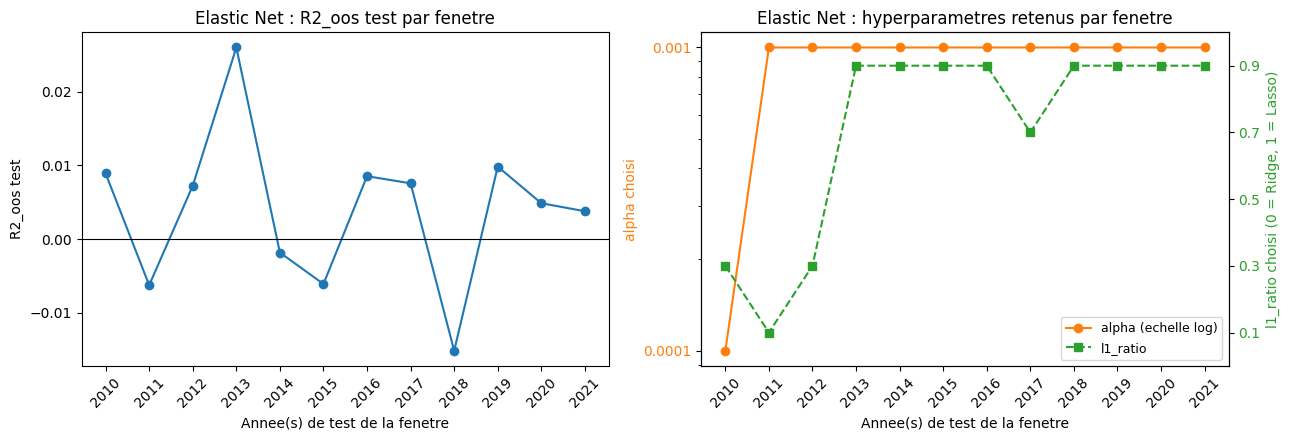

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Panneau 1 : R2_oos test par fenetre (inchange) ---
axes[0].plot(resultats_par_fenetre['annee_test'], resultats_par_fenetre['r2_oos_test'],
             marker='o', color='tab:blue')
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_xlabel("Annee(s) de test de la fenetre")
axes[0].set_ylabel("R2_oos test")
axes[0].set_title("Elastic Net : R2_oos test par fenetre")
axes[0].tick_params(axis='x', rotation=45)

# --- Panneau 2 : les DEUX hyperparametres, deux axes Y ---
ax_alpha = axes[1]
ax_l1 = ax_alpha.twinx()

trace_alpha, = ax_alpha.plot(
    resultats_par_fenetre['annee_test'], resultats_par_fenetre['alpha'],
    marker='o', color='tab:orange', label='alpha (echelle log)')
ax_alpha.set_yscale('log')
ax_alpha.set_yticks(config.GRILLE_ALPHA_ELASTIC_NET)
ax_alpha.set_yticklabels([f"{v:g}" for v in config.GRILLE_ALPHA_ELASTIC_NET])
ax_alpha.set_xlabel("Annee(s) de test de la fenetre")
ax_alpha.set_ylabel("alpha choisi", color='tab:orange')
ax_alpha.tick_params(axis='y', labelcolor='tab:orange')
ax_alpha.tick_params(axis='x', rotation=45)

trace_l1, = ax_l1.plot(
    resultats_par_fenetre['annee_test'], resultats_par_fenetre['l1_ratio'],
    marker='s', linestyle='--', color='tab:green', label='l1_ratio')
ax_l1.set_ylim(0, 1)
ax_l1.set_yticks(config.GRILLE_L1_RATIO_ELASTIC_NET)
ax_l1.set_ylabel("l1_ratio choisi (0 = Ridge, 1 = Lasso)", color='tab:green')
ax_l1.tick_params(axis='y', labelcolor='tab:green')

ax_alpha.set_title("Elastic Net : hyperparametres retenus par fenetre")
ax_alpha.legend(handles=[trace_alpha, trace_l1], loc='best', fontsize=9)

plt.tight_layout()
plt.show()

## 6. Stabilité de la sélection de variables (toutes les fenêtres)

Un coefficient non nul sur la **dernière fenêtre** ne dit rien sur sa **fiabilité** : une
variable peut être retenue une année et ignorée la suivante, simplement parce que la
meilleure combinaison `(alpha, l1_ratio)` a légèrement changé. L'idée de la **sélection de
stabilité** (*stability selection*, Meinshausen & Bühlmann, 2010) est de regarder, sur
**toutes** les fenêtres, à quelle fréquence chaque prédicteur a été gardé — l'équivalent,
pour un modèle régularisé, de la significativité par Fama-MacBeth du notebook 04 (les
coefficients de l'Elastic Net n'ont pas de loi d'échantillonnage classique exploitable pour
un test de significativité au sens habituel).

Pour chaque prédicteur :
- **Fréquence de sélection** : % des fenêtres où son coefficient est non nul.
- **Coefficient moyen (fenêtres sélectionnées)** : sa magnitude moyenne, uniquement sur les
  fenêtres où il a été gardé (une moyenne sur toutes les fenêtres, zéros compris, écraserait
  artificiellement les variables rarement sélectionnées).
- **Signe majoritaire** : cohérence du signe d'une fenêtre à l'autre (un signe qui change
  souvent est un signal d'instabilité, même si la fréquence de sélection est élevée).

In [11]:
# Detail brut : le coefficient de chaque predicteur, fenetre par fenetre
# (utile pour reperer d'ou vient une instabilite reperee ci-dessus)
rap.table('coefficients_par_fenetre').round(4)

,mom1m,mom6m,mom12m,chmom,indmom,maxret,mvel1,dolvol,turn,std_turn,...,agr,chcsho,egr,invest,gma,operprof,roaq,roeq,acc,chtx
fenetre,,,,,,,,,,,,,,,,,,,,,
0,-0.0038,0.0030,0.0050,-0.0033,0.0025,-0.0000,0.0021,-0.0034,-0.0104,0.0096,...,0.0013,-0.0002,-0.0004,-0.0024,0.0015,0.0019,0.0011,0.0008,-0.0003,0.0004
1,-0.0029,0.0026,0.0058,-0.0029,0.0038,-0.0012,0.0012,-0.0015,-0.0095,0.0089,...,0.0022,-0.0003,-0.0006,-0.0021,0.0029,0.0008,-0.0000,0.0000,-0.0017,-0.0000
2,-0.0016,0.0026,0.0051,-0.0020,0.0030,-0.0029,0.0000,-0.0002,-0.0073,0.0074,...,0.0023,-0.0000,-0.0005,-0.0011,0.0013,0.0004,0.0002,0.0000,-0.0006,0.0000
3,-0.0000,0.0000,0.0058,-0.0000,0.0018,-0.0011,-0.0000,-0.0000,-0.0000,0.0013,...,0.0022,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
4,-0.0000,0.0000,0.0054,-0.0000,0.0015,-0.0001,-0.0000,-0.0000,-0.0000,0.0009,...,0.0018,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
5,-0.0000,0.0001,0.0051,-0.0000,0.0013,-0.0000,-0.0000,-0.0000,-0.0000,0.0005,...,0.0017,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
6,-0.0000,0.0004,0.0025,-0.0000,0.0004,-0.0000,-0.0000,-0.0001,-0.0000,0.0004,...,0.0021,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
7,-0.0000,0.0011,0.0024,-0.0000,0.0007,-0.0004,-0.0000,-0.0003,-0.0000,0.0006,...,0.0024,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000
8,-0.0000,0.0005,0.0019,-0.0000,0.0004,-0.0000,-0.0000,-0.0000,-0.0000,0.0000,...,0.0019,-0.0000,-0.0000,-0.0000,0.0000,0.0000,0.0000,0.0000,-0.0000,0.0000


In [12]:
stabilite = pd.read_parquet(config.FICHIER_IMPORTANCE_ELASTIC_NET)

print(f"Coefficients agreges sur {rap.valeur('n_fenetres')} fenetres x "
      f"{rap.valeur('n_predicteurs')} predicteurs.")
print()
print(f"{rap.valeur('stab_n_toujours_selectionnes')} / {rap.valeur('stab_n_predicteurs')} "
      "predicteurs selectionnes dans TOUTES les fenetres.")
print(f"{rap.valeur('stab_n_jamais_selectionnes')} / {rap.valeur('stab_n_predicteurs')} "
      "predicteurs jamais selectionnes (coefficient toujours ramene a 0).")
print()
print("Top 20 des predicteurs les plus stables (frequence de selection, puis magnitude) :")
stabilite.head(20).round(3)

Coefficients agreges sur 12 fenetres x 30 predicteurs.

3 / 30 predicteurs selectionnes dans TOUTES les fenetres.
0 / 30 predicteurs jamais selectionnes (coefficient toujours ramene a 0).

Top 20 des predicteurs les plus stables (frequence de selection, puis magnitude) :


,frequence_selection_pct,coef_moyen_si_selectionne,signe_dominant,coherence_signe_pct
agr,100.000,0.002,1,100.0
sp,100.000,0.002,1,100.0
indmom,100.000,0.001,1,100.0
mom12m,91.667,0.004,1,100.0
mom6m,83.333,0.001,1,100.0
cfp,83.333,0.001,1,100.0
std_turn,66.667,0.004,1,100.0
bm,66.667,0.001,1,100.0
dolvol,50.000,-0.001,-1,100.0
maxret,41.667,-0.001,-1,100.0


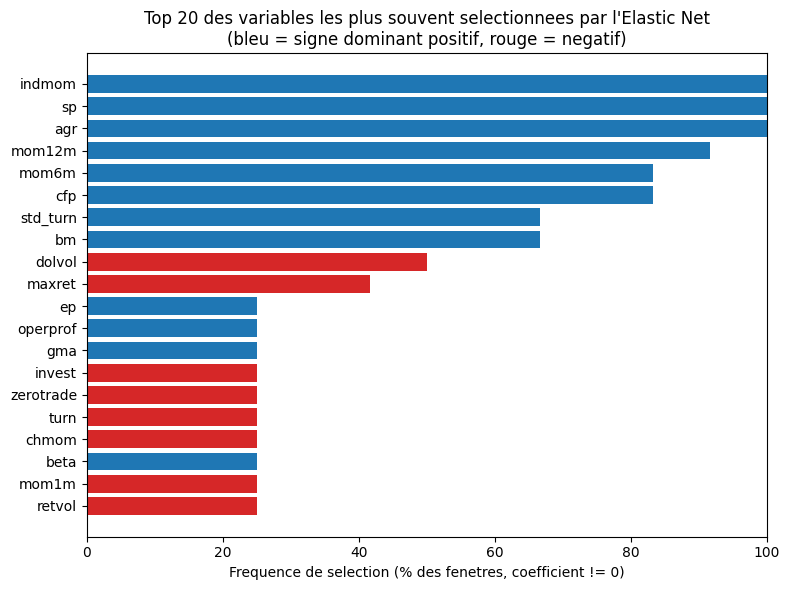

In [13]:
top20_stab = stabilite.head(20).sort_values('frequence_selection_pct')
couleurs = ['tab:blue' if s > 0 else 'tab:red' for s in top20_stab['signe_dominant']]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_stab.index, top20_stab['frequence_selection_pct'], color=couleurs)
ax.set_xlim(0, 100)
ax.set_xlabel("Frequence de selection (% des fenetres, coefficient != 0)")
ax.set_title("Top 20 des variables les plus souvent selectionnees par l'Elastic Net\n"
             "(bleu = signe dominant positif, rouge = negatif)")
plt.tight_layout()
plt.show()

## 9. Résumé

- Hyperparamètres (`alpha`, `l1_ratio`) choisis par recherche sur grille, ré-évalués **à
  chaque fenêtre** sur sa propre `validation` (jamais de validation croisée aléatoire,
  jamais sur `test`).
- Même métrique et même logique de fenêtres que le notebook 04, pour une comparaison équitable.
- **Stabilité de la sélection (section 6bis)** : fréquence de sélection, magnitude moyenne
  et cohérence de signe, agrégées sur **toutes** les fenêtres.

**Étape suivante :** `python scripts/etape06_modele_lightgbm.py`.